In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, recall_score, f1_score


In [2]:
def train_decision_tree(depth,X_train_scaled, y_train, X_test_scaled, y_test, class_labels=None):
    # Train Decision Tree Classifier with max_depth=20
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = clf.predict(X_test_scaled)
    # Compute Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)), 
                yticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Decision Tree (Depth={depth}) - Confusion Matrix")
    plt.show()

    # Accuracy Score
    accuracy = accuracy_score(y_test, y_pred)

    # Sensitivity (Recall Macro-Averaged)
    sensitivity = recall_score(y_test, y_pred, average='macro')

    # F1 Score Calculation
    f1 = f1_score(y_test, y_pred, average='macro')

    # Specificity Calculation
    specificity_list = []
    for i in range(len(conf_matrix)):
        tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
        fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity (Macro Recall): {sensitivity:.4f}")
    print(f"Specificity (Macro Specificity): {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [3]:
# Load the robot data
robot_df = pd.read_csv("Classification_of_Robots_from_their_conversation_sequence.csv")
robot_df.head()

,Robot,num1,num2,num3,num4,num5,num6,num7,num8,num9,num10
0,1,2,5,2,5,6,2,1,8.000000e+00,1.000000e+00,3.000000e+00
1,2,1747,1749,1751,1758,1765,1767,1772,1.774000e+03,1.783000e+03,1.785000e+03
2,3,65056,195168,1561344,7806720,31226880,187361280,749445120,6.745006e+09,6.745006e+09,6.745006e+09
3,4,2855,2860,2865,2870,2875,2880,2885,2.890000e+03,2.895000e+03,2.900000e+03
4,5,11440,57200,286000,1430000,7150000,35750000,178750000,8.937500e+08,4.468750e+09,2.234375e+10


In [4]:
# Separate features and target variable
X = robot_df.iloc[:, 1:]  # Features: num1 to num10
y = robot_df.iloc[:, 0]   # Target: robotID (classification labels)

# Add prefix "Robot" to target labels and encode them
y = y.astype(str).apply(lambda x: f"Robot{x}")  # Prefix "Robot"
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Convert to numeric labels

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Normalize the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

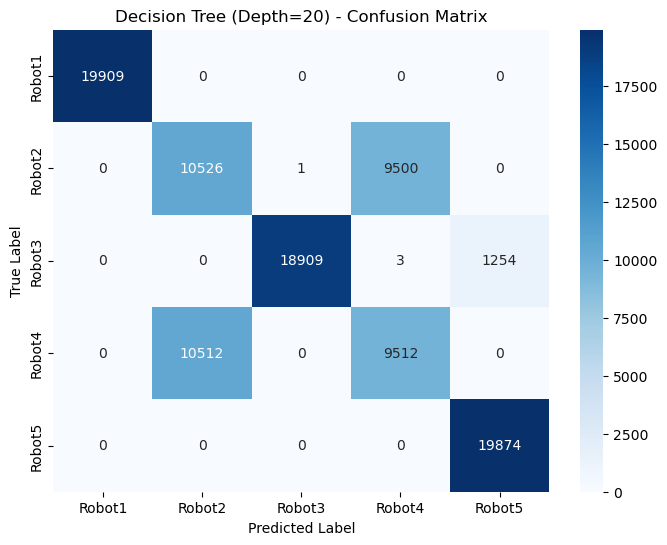

Accuracy: 0.7873
Sensitivity (Macro Recall): 0.7877
Specificity (Macro Specificity): 0.9468
F1 Score: 0.7874

Classification Report:
               precision    recall  f1-score   support

      Robot1       1.00      1.00      1.00     19909
      Robot2       0.50      0.53      0.51     20027
      Robot3       1.00      0.94      0.97     20166
      Robot4       0.50      0.48      0.49     20024
      Robot5       0.94      1.00      0.97     19874

    accuracy                           0.79    100000
   macro avg       0.79      0.79      0.79    100000
weighted avg       0.79      0.79      0.79    100000



In [6]:
train_decision_tree(20,X_train_scaled,y_train,X_test_scaled,y_test,label_encoder.classes_)

In [7]:
depth_list = [1, 5, 10, 20, 50, 100]
random_seed_list = [42, 500, 3500, 10000]
results = {}
for random_seed in random_seed_list:
    for depth in depth_list:
        clf = DecisionTreeClassifier(max_depth=depth, random_state=random_seed)
        clf.fit(X_train_scaled, y_train)
        y_pred_depth = clf.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred_depth)
        results[random_seed, depth] = acc
        print(f"Random seed={random_seed}, max_depth={depth} -> Accuracy: {acc:.4f}")

Random seed=42, max_depth=1 -> Accuracy: 0.3978
Random seed=42, max_depth=5 -> Accuracy: 0.7412
Random seed=42, max_depth=10 -> Accuracy: 0.7754
Random seed=42, max_depth=20 -> Accuracy: 0.7873
Random seed=42, max_depth=50 -> Accuracy: 0.8025
Random seed=42, max_depth=100 -> Accuracy: 0.8166
Random seed=500, max_depth=1 -> Accuracy: 0.3978
Random seed=500, max_depth=5 -> Accuracy: 0.7412
Random seed=500, max_depth=10 -> Accuracy: 0.7754
Random seed=500, max_depth=20 -> Accuracy: 0.7873
Random seed=500, max_depth=50 -> Accuracy: 0.8025
Random seed=500, max_depth=100 -> Accuracy: 0.8165
Random seed=3500, max_depth=1 -> Accuracy: 0.3978
Random seed=3500, max_depth=5 -> Accuracy: 0.7412
Random seed=3500, max_depth=10 -> Accuracy: 0.7754
Random seed=3500, max_depth=20 -> Accuracy: 0.7873
Random seed=3500, max_depth=50 -> Accuracy: 0.8025
Random seed=3500, max_depth=100 -> Accuracy: 0.8165
Random seed=10000, max_depth=1 -> Accuracy: 0.3978
Random seed=10000, max_depth=5 -> Accuracy: 0.7412
R